# Probabilistic Thunder Verification Plots

## Use Description

This notebook loads merged NBM probabilistic thunder verification data and produces exploratory verification graphics for day/night, regional, and monsoon-focused subsets. It is set up for interactive reruns where you adjust a small number of configuration variables near the top and then execute only the plot sections you need.

## What This Notebook Does

- Loads a filtered parquet verification dataset for one thunder threshold and initialization cycle.
- Splits the sample into day and night valid-time groups.
- Builds CSI-versus-threshold and sharpness plots by forecast hour.
- Builds reliability and ROC plots for thunder, lightning, and combined event definitions.
- Repeats the same diagnostics for a Southwest monsoon WFO subset.

## Expected Inputs

The parquet dataset used here should already include forecast metadata and observed event columns such as `point_prob`, `forecast_hour`, `valid_date`, `region`, `wfo`, `observed_thunder`, `observed_lightning`, and `observed_combined`.

## Typical Workflow

1. Run the import/setup cell.
2. Set the output plot directory.
3. Choose `tstm_type`, `init_cyle`, and any forecast-hour subset options.
4. Run the data-load cell and inspect the dataset preview if needed.
5. Run the day/night split cell.
6. Run whichever plotting sections are relevant for the current analysis.

In [1]:
# import gc
# gc.collect()

import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plot_dir = r"N:\data\nbm\prob_thunder\verif_results\plots"

## Configuration and Data Load

These first code cells define the plotting output directory, choose the threshold/cycle combination to analyze, and optionally restrict the forecast-hour range before loading the parquet dataset.

The forecast-hour subset is applied directly in the parquet read filter, which keeps memory use manageable when the source dataset is large. Use this section whenever you want to switch between `tstm01`, `tstm03`, `tstm06`, or `tstm12`, or compare the `0100` and `1300` cycles.

In [11]:
tstm_type = 'tstm12'  # Change to 'tstm01' for the other dataset
init_cyle = '0100'  # Change to '1300' for the other dataset
plot_fcst_hour_subset = True
plot_fcst_hour_type = "4to7"  # Change to "4to7" for the other forecast hour range
plot_fcst_hours = {"1to3": [0, 78], "4to7": [77, 168]}  # Define forecast hour ranges for plotting

data_path = rf"N:\data\nbm\prob_thunder\verif_results\prob_thunder_{tstm_type}_{init_cyle}.parquet"

# Push the forecast-hour filter to the parquet reader so pandas never loads the
# full ~40M row dataset into RAM.  PyArrow applies the predicate at the row-group
# level before allocating memory, keeping df_all to only the needed rows.
if plot_fcst_hour_subset:
    if plot_fcst_hour_type not in plot_fcst_hours:
        raise KeyError(
            f"plot_fcst_hour_type '{plot_fcst_hour_type}' not found in plot_fcst_hours. "
            f"Available keys: {list(plot_fcst_hours.keys())}"
        )
    _fh = plot_fcst_hours[plot_fcst_hour_type]
    _filters = [("forecast_hour", ">=", _fh[0]), ("forecast_hour", "<=", _fh[1])]
    df_all = pd.read_parquet(data_path, engine="pyarrow", filters=_filters)
    del _fh, _filters
else:
    df_all = pd.read_parquet(data_path, engine="pyarrow")

print(f"Loaded df_all: {df_all.shape}")

Loaded df_all: (24342048, 21)


In [12]:
df_all.head()

,station,lat,lon,point_prob,min,max,mean,median,pct90,majority,...,observed_lightning,observed_combined,nbm_version,forecast_hour,threshold_type,cycle,valid_date,wfo,state,region
0,RQE,35.6575,-109.0614,0,0,0,0.0,0,0,0,...,0.0,0.0,4.1,77,tstm12,0100,2023-03-01,FGZ,AZ,WR
1,FLG,35.1403,-111.6722,0,0,0,0.0,0,0,0,...,0.0,0.0,4.1,77,tstm12,0100,2023-03-01,FGZ,AZ,WR
2,GCN,35.9461,-112.1547,0,0,0,0.0,0,0,0,...,0.0,0.0,4.1,77,tstm12,0100,2023-03-01,FGZ,AZ,WR
3,IGM,35.2577,-113.9330,0,0,0,0.0,0,0,0,...,0.0,0.0,4.1,77,tstm12,0100,2023-03-01,VEF,NV,WR
4,INW,35.0219,-110.7225,0,0,0,0.0,0,0,0,...,0.0,0.0,4.1,77,tstm12,0100,2023-03-01,FGZ,AZ,WR


In [13]:
print(df_all["forecast_hour"].unique())

[ 77  83  89  95 101 107 113 119 125 131 137 143 149 155 161 167]


## Day and Night Split

This section partitions the loaded sample into day and night valid-time subsets using the initialization cycle plus forecast hour. Downstream plotting cells assume `df_day` and `df_night` already exist, so rerun this section any time you change the threshold, cycle, or forecast-hour subset.

In [14]:
# CREATE DAY/NIGHT SPLIT

import gc

# Derive the valid UTC hour using a scalar cycle offset — avoids per-row string parsing.
# valid_date carries no time component, so: valid_hour = (init_hour + forecast_hour) % 24
_cycle_hour = int(init_cyle[:2])
valid_hour = (_cycle_hour + df_all['forecast_hour']) % 24

# Day: valid_hour > 18Z or valid_hour <= 6Z
# Views only — no .copy() — to avoid duplicating the (now much smaller) dataset.
day_mask = (valid_hour > 18) | (valid_hour <= 6)

df_day = df_all[day_mask]
df_night = df_all[~day_mask]

del valid_hour, day_mask
gc.collect()

# Set labels used by downstream plot titles and output filenames.
# The FH filter was already applied at read time; just set the annotation strings here.
fcst_subset_title = ""
fcst_subset_file_suffix = ""

if plot_fcst_hour_subset:
    fh_start, fh_end = plot_fcst_hours[plot_fcst_hour_type]
    fcst_subset_title = f" | Day {plot_fcst_hour_type.replace('to', '-')}"
    fcst_subset_file_suffix = f"_{plot_fcst_hour_type}"
    print(f"Forecast hour subset '{plot_fcst_hour_type}' ({fh_start}–{fh_end}) applied at read time.")

print(f"df_day shape:   {df_day.shape}")
print(f"df_night shape: {df_night.shape}")
print(f"Total:          {df_day.shape[0] + df_night.shape[0]} (df_all rows: {df_all.shape[0]})")

Forecast hour subset '4to7' (77–168) applied at read time.
df_day shape:   (12214149, 21)
df_night shape: (12127899, 21)
Total:          24342048 (df_all rows: 24342048)


## Regional CSI and Sharpness Plots

This section evaluates forecast discrimination by region and by forecast hour. Each figure compares day and night CSI curves across probability thresholds and pairs them with sharpness histograms so you can judge both forecast skill and forecast usage.

Outputs are written to the configured plot directory with filenames that include threshold, cycle, region, and any forecast-hour subset tag.

C:\Users\chad.kahler\AppData\Local\Temp\ipykernel_17236\3235756970.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


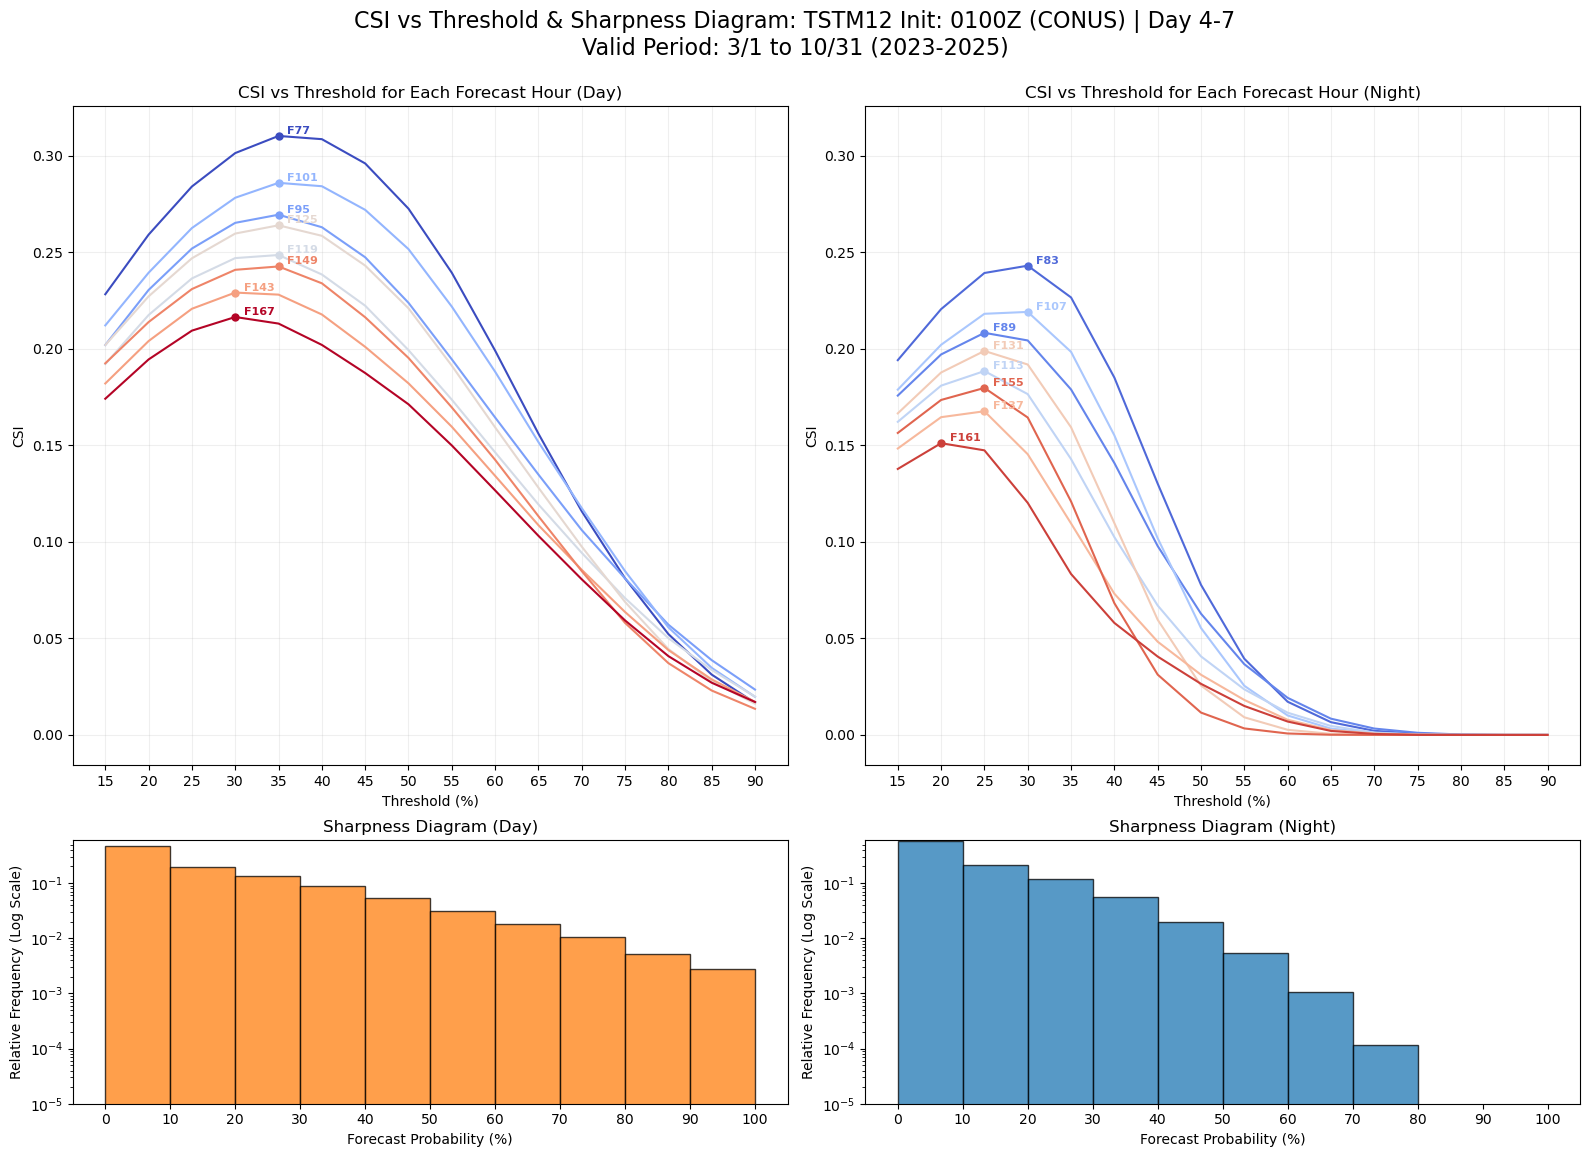

C:\Users\chad.kahler\AppData\Local\Temp\ipykernel_17236\3235756970.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


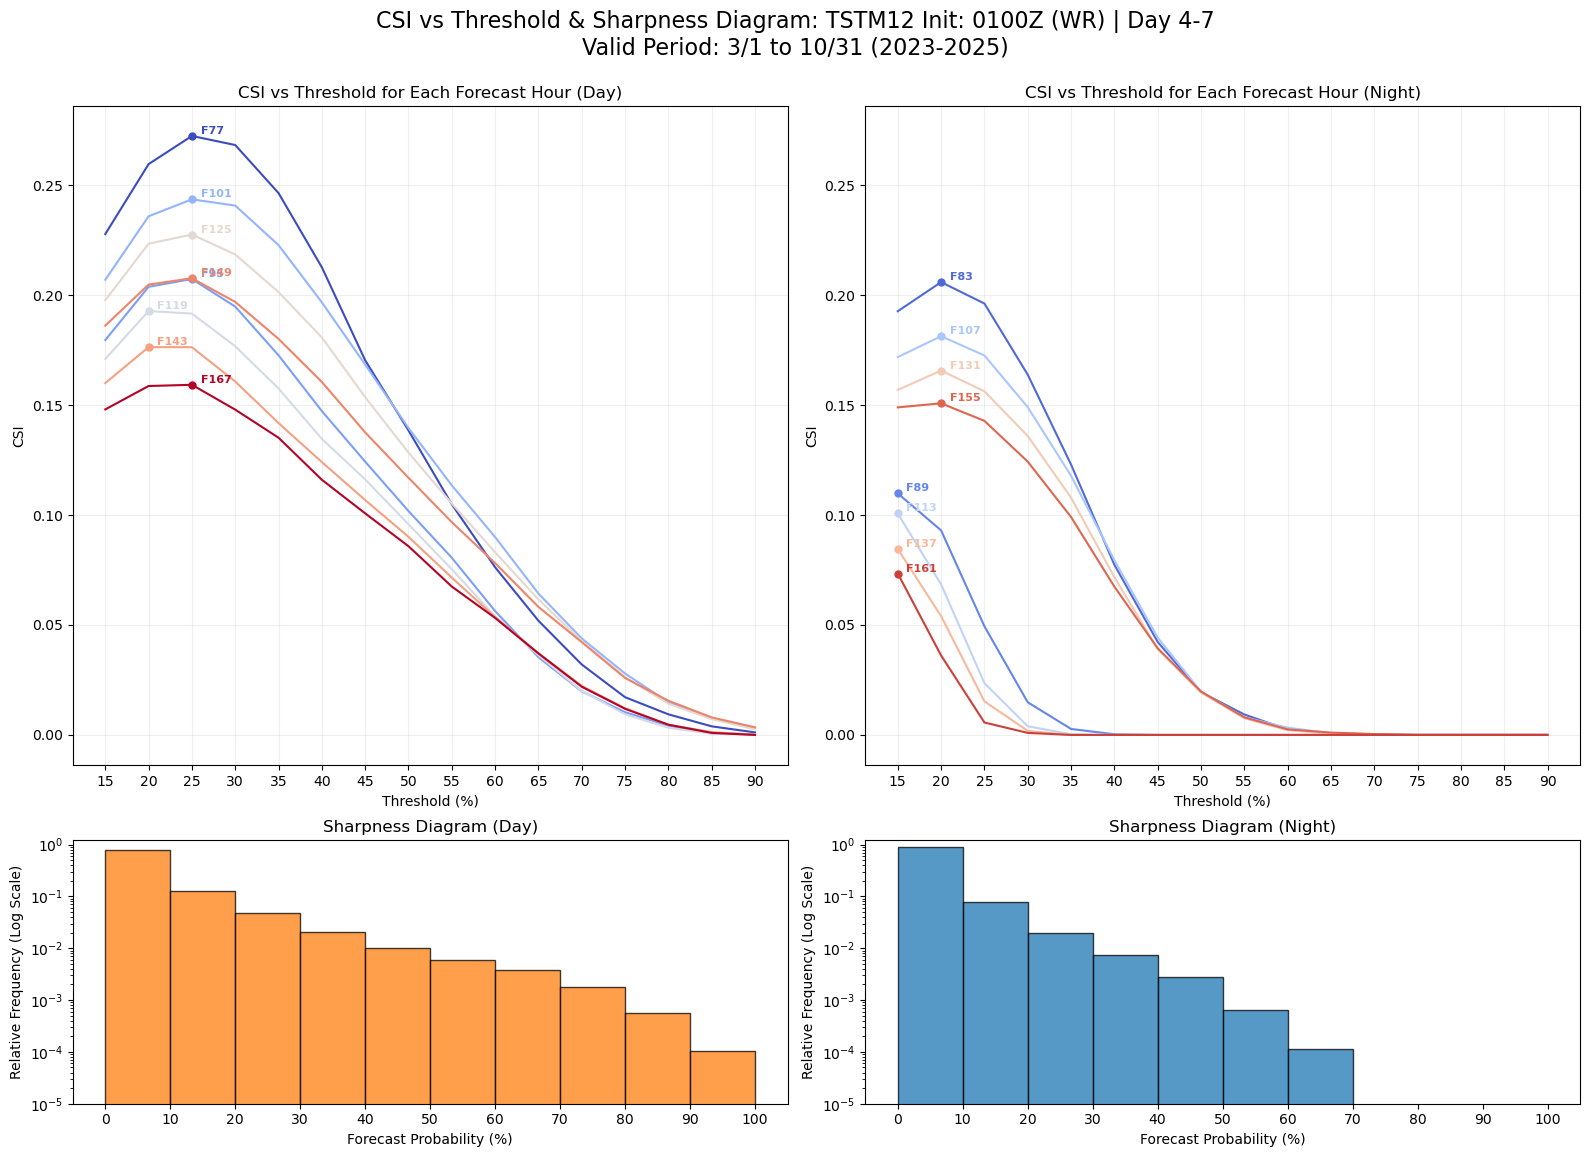

C:\Users\chad.kahler\AppData\Local\Temp\ipykernel_17236\3235756970.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


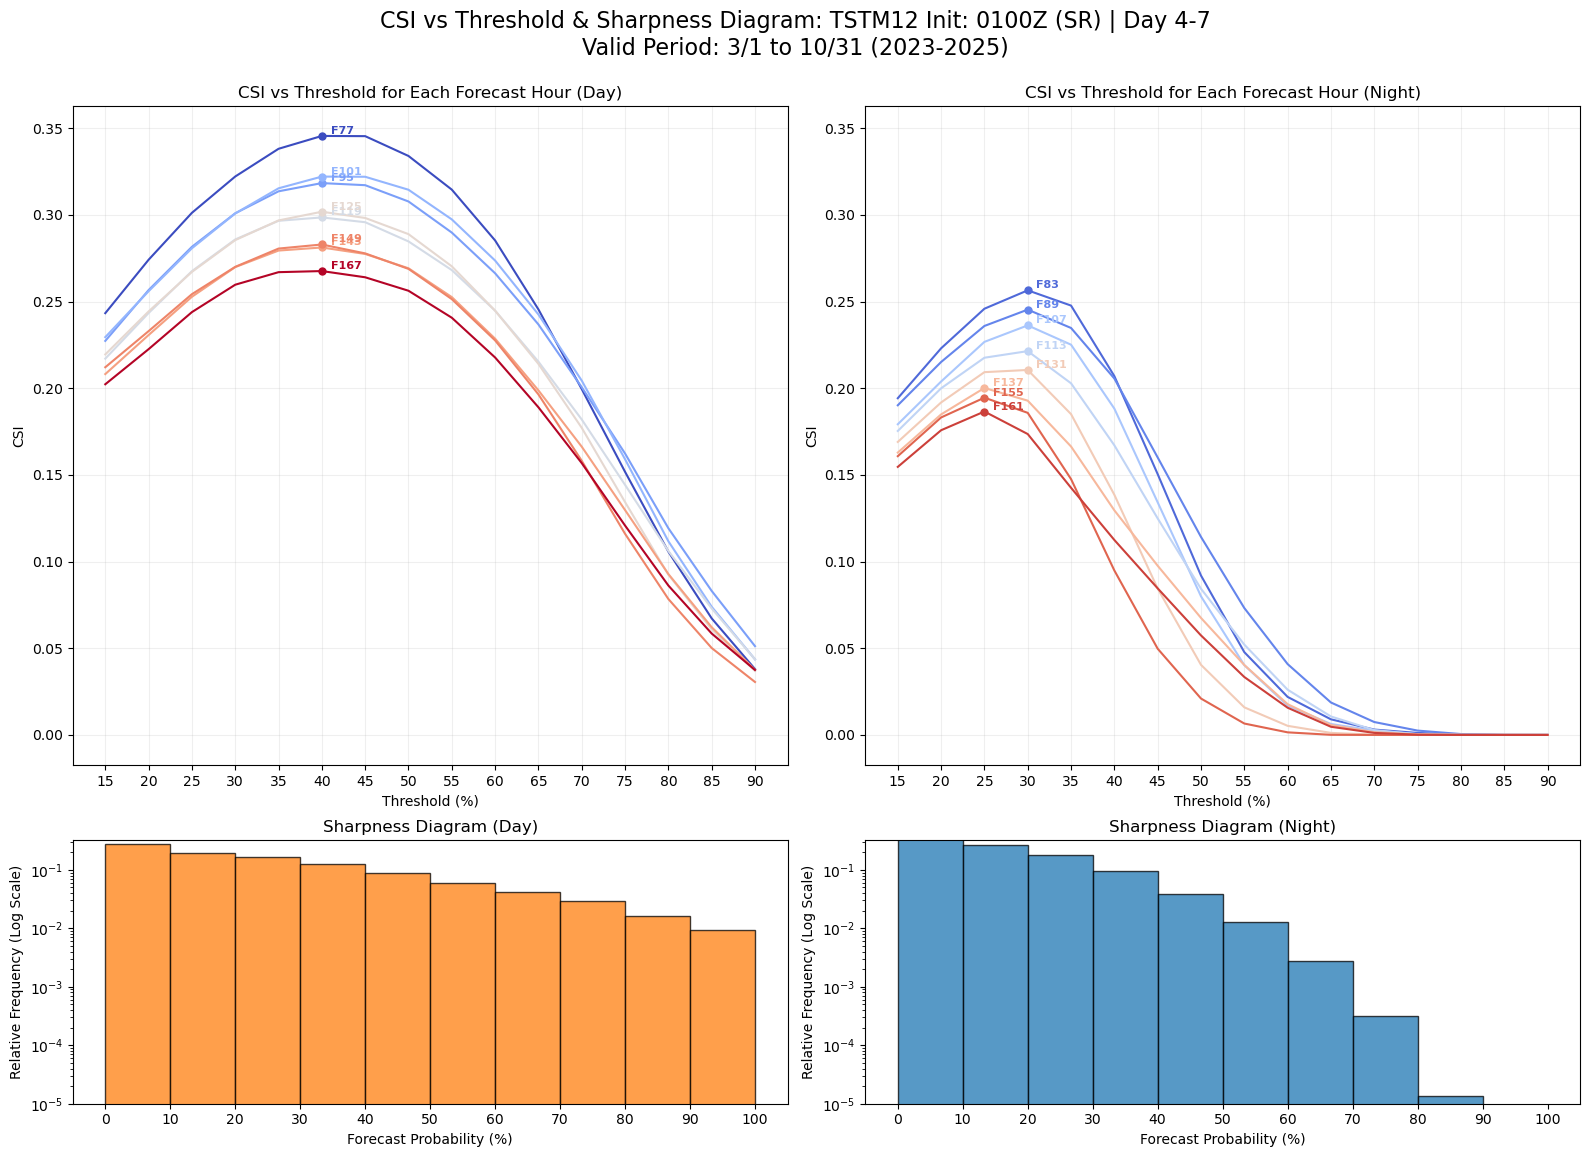

C:\Users\chad.kahler\AppData\Local\Temp\ipykernel_17236\3235756970.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


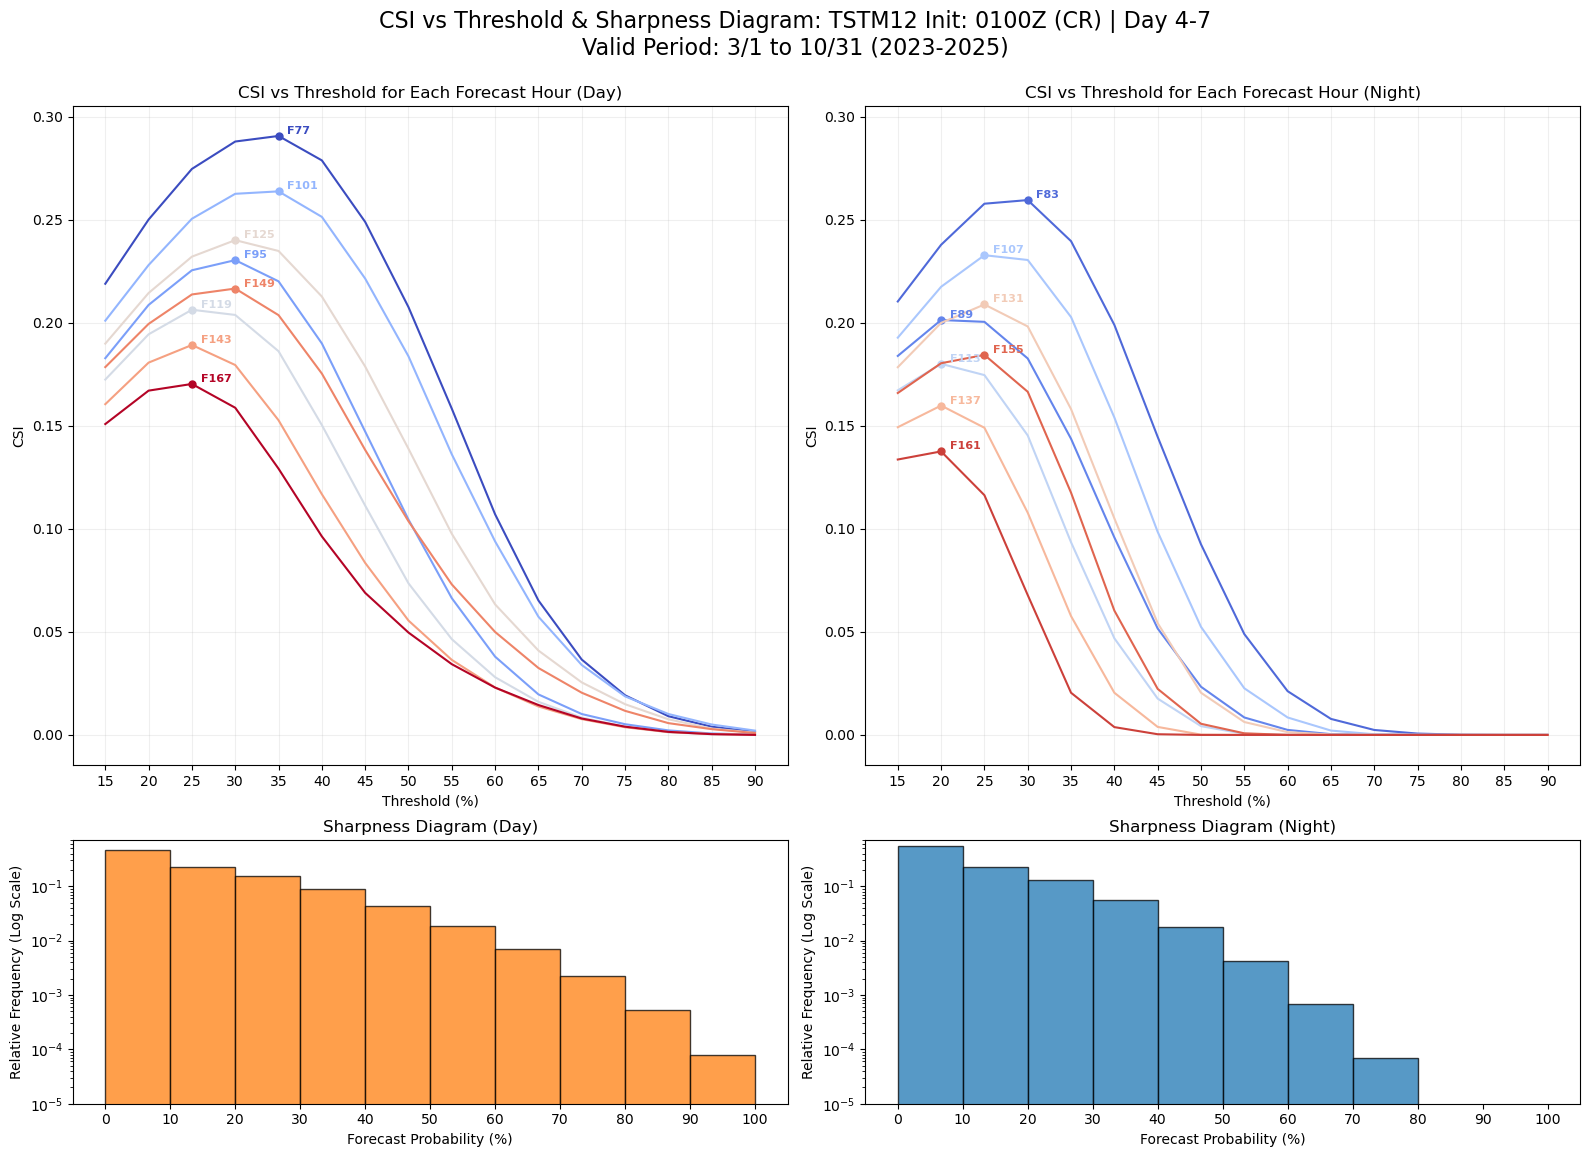

C:\Users\chad.kahler\AppData\Local\Temp\ipykernel_17236\3235756970.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


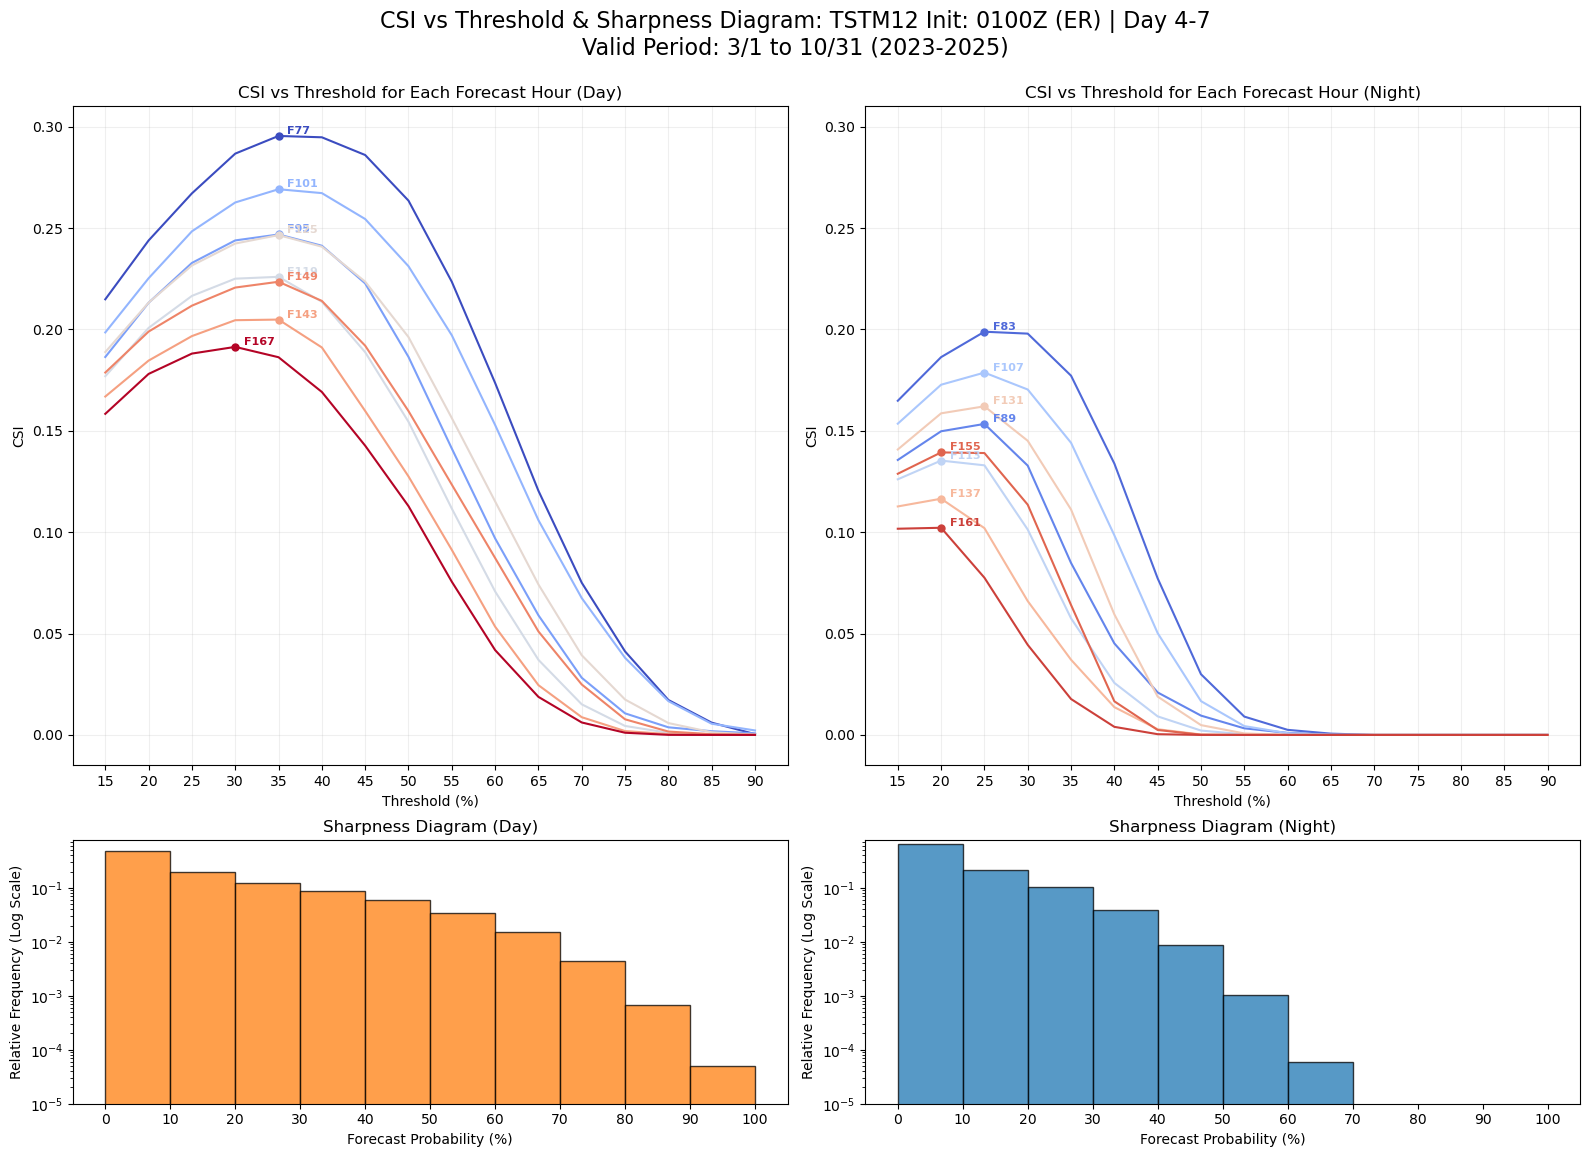

In [15]:
##  REGIONAL CSI AND SHARPNESS PLOTS

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import os

# Fallbacks let this cell run even if the split cell was not run first.
fcst_subset_title = globals().get('fcst_subset_title', '')
fcst_subset_file_suffix = globals().get('fcst_subset_file_suffix', '')

thresholds = np.arange(15, 95, 5) # 15 to 90

def compute_csi_by_fh_thresh(df, obs_col='observed_thunder'):
    df_eval = df[['point_prob', obs_col, 'forecast_hour']].dropna()
    obs = df_eval[obs_col].astype(int).eq(1)
    
    results = []
    for t in thresholds:
        pred = df_eval['point_prob'] >= t
        hits = (pred & obs).astype(int)
        misses = (~pred & obs).astype(int)
        fa = (pred & ~obs).astype(int)
        
        df_stats = pd.DataFrame({
            'forecast_hour': df_eval['forecast_hour'],
            'hits': hits,
            'misses': misses,
            'fa': fa
        })
        
        grouped = df_stats.groupby('forecast_hour').sum()
        
        csi = grouped['hits'] / (grouped['hits'] + grouped['misses'] + grouped['fa'])
        
        res = pd.DataFrame({
            'forecast_hour': grouped.index,
            'threshold': t,
            'CSI': csi
        })
        
        results.append(res)
        
        del df_stats, grouped, csi, res, pred, hits, misses, fa
        
    import gc
    del df_eval, obs
    gc.collect()
    
    if not results:
        return pd.DataFrame()
        
    return pd.concat(results, ignore_index=True)

years = [2023, 2024, 2025]
start_month, start_day = 3, 1
end_month, end_day = 10, 31

date_col = 'valid_date' # Change to the correct date/datetime column

time_d_all = pd.to_datetime(df_day[date_col]) + pd.to_timedelta(df_day['forecast_hour'], unit='h')
time_n_all = pd.to_datetime(df_night[date_col]) + pd.to_timedelta(df_night['forecast_hour'], unit='h')

def get_date_mask(time_series, years, start_m, start_d, end_m, end_d):
    y_mask = time_series.dt.year.isin(years)
    mmdd = time_series.dt.month * 100 + time_series.dt.day
    start_val = start_m * 100 + start_d
    end_val = end_m * 100 + end_d
    return y_mask & (mmdd >= start_val) & (mmdd <= end_val)

mask_d_all = get_date_mask(time_d_all, years, start_month, start_day, end_month, end_day)
mask_n_all = get_date_mask(time_n_all, years, start_month, start_day, end_month, end_day)

df_day_filtered = df_day[mask_d_all]
df_night_filtered = df_night[mask_n_all]

regions = ['CONUS', 'WR', 'SR', 'CR', 'ER']

for region in regions:
    if region == 'CONUS':
        df_d = df_day_filtered
        df_n = df_night_filtered
    else:
        df_d = df_day_filtered[df_day_filtered['region'] == region]
        df_n = df_night_filtered[df_night_filtered['region'] == region]
        
    stats_day = compute_csi_by_fh_thresh(df_d)
    stats_night = compute_csi_by_fh_thresh(df_n)
    
    all_fhs = set()
    if not stats_day.empty: 
        all_fhs.update(stats_day['forecast_hour'].unique())
    if not stats_night.empty: 
        all_fhs.update(stats_night['forecast_hour'].unique())
    
    if not all_fhs:
        print(f"No data for {region}, skipping.")
        continue
        
    min_fh, max_fh = min(all_fhs), max(all_fhs)
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1])
    
    ax_top_d = fig.add_subplot(gs[0, 0])
    ax_top_n = fig.add_subplot(gs[0, 1], sharey=ax_top_d, sharex=ax_top_d)
    ax_bot_d = fig.add_subplot(gs[1, 0])
    ax_bot_n = fig.add_subplot(gs[1, 1], sharey=ax_bot_d, sharex=ax_bot_d)
    
    fig.suptitle(f'CSI vs Threshold & Sharpness Diagram: {tstm_type.upper()} Init: {init_cyle}Z ({region}){fcst_subset_title}\nValid Period: {start_month}/{start_day} to {end_month}/{end_day} ({min(years)}-{max(years)})', fontsize=16, y=0.96)
    
    cmap = cm.get_cmap('coolwarm')
    
    def plot_csi_curves(ax, stats, title):
        if stats.empty:
            return
        for fh, group in stats.groupby('forecast_hour'):
            group = group.sort_values('threshold')
            color_val = (fh - min_fh) / (max_fh - min_fh) if max_fh > min_fh else 0.5
            c = cmap(color_val)
            ax.plot(group['threshold'], group['CSI'], color=c, label=f'F{fh}')
            
            # Highlight max CSI with a dot and label
            if not group['CSI'].isna().all():
                max_csi_idx = group['CSI'].idxmax()
                max_row = group.loc[max_csi_idx]
                ax.plot(max_row['threshold'], max_row['CSI'], marker='o', markersize=5, color=c)
                ax.text(max_row['threshold'] + 1, max_row['CSI'], f"F{fh}", color=c, fontsize=8, fontweight='bold', va='bottom')
        
        ax.set_title(title)
        ax.set_xlabel('Threshold (%)')
        ax.set_ylabel('CSI')
        ax.set_xticks(thresholds)
        ax.grid(alpha=0.2)
        
    plot_csi_curves(ax_top_d, stats_day, 'CSI vs Threshold for Each Forecast Hour (Day)')
    plot_csi_curves(ax_top_n, stats_night, 'CSI vs Threshold for Each Forecast Hour (Night)')
    
    def plot_sharpness(ax, df_sub, color, title):
        probs = df_sub['point_prob'].dropna()
        if len(probs) > 0:
            weights = np.ones_like(probs) / len(probs)
            ax.hist(probs, bins=np.arange(0, 110, 10), weights=weights, color=color, edgecolor='black', alpha=0.75)
        
        ax.set_title(title)
        ax.set_yscale('log')
        # Prevent bottom of plot from collapsing
        ax.set_ylim(bottom=1e-5)
        ax.set_xlabel('Forecast Probability (%)')
        ax.set_ylabel('Relative Frequency (Log Scale)')
        ax.set_xticks(np.arange(0, 110, 10))
        
    plot_sharpness(ax_bot_d, df_d, 'tab:orange', 'Sharpness Diagram (Day)')
    plot_sharpness(ax_bot_n, df_n, 'tab:blue', 'Sharpness Diagram (Night)')
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.88)
    
    save_path = os.path.join(plot_dir, f'csi_sharpness_{tstm_type}_{init_cyle}_{region}{fcst_subset_file_suffix}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

## Monsoon-Focused CSI and Sharpness

This section repeats the CSI and sharpness workflow for a fixed set of Southwest and Intermountain West forecast offices during the warm-season monsoon window. Use it when you want a regionalized diagnostic that better isolates monsoon-season thunder behavior than the broad CONUS or census-style regional summaries.

C:\Users\chad.kahler\AppData\Local\Temp\ipykernel_17236\2410607893.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


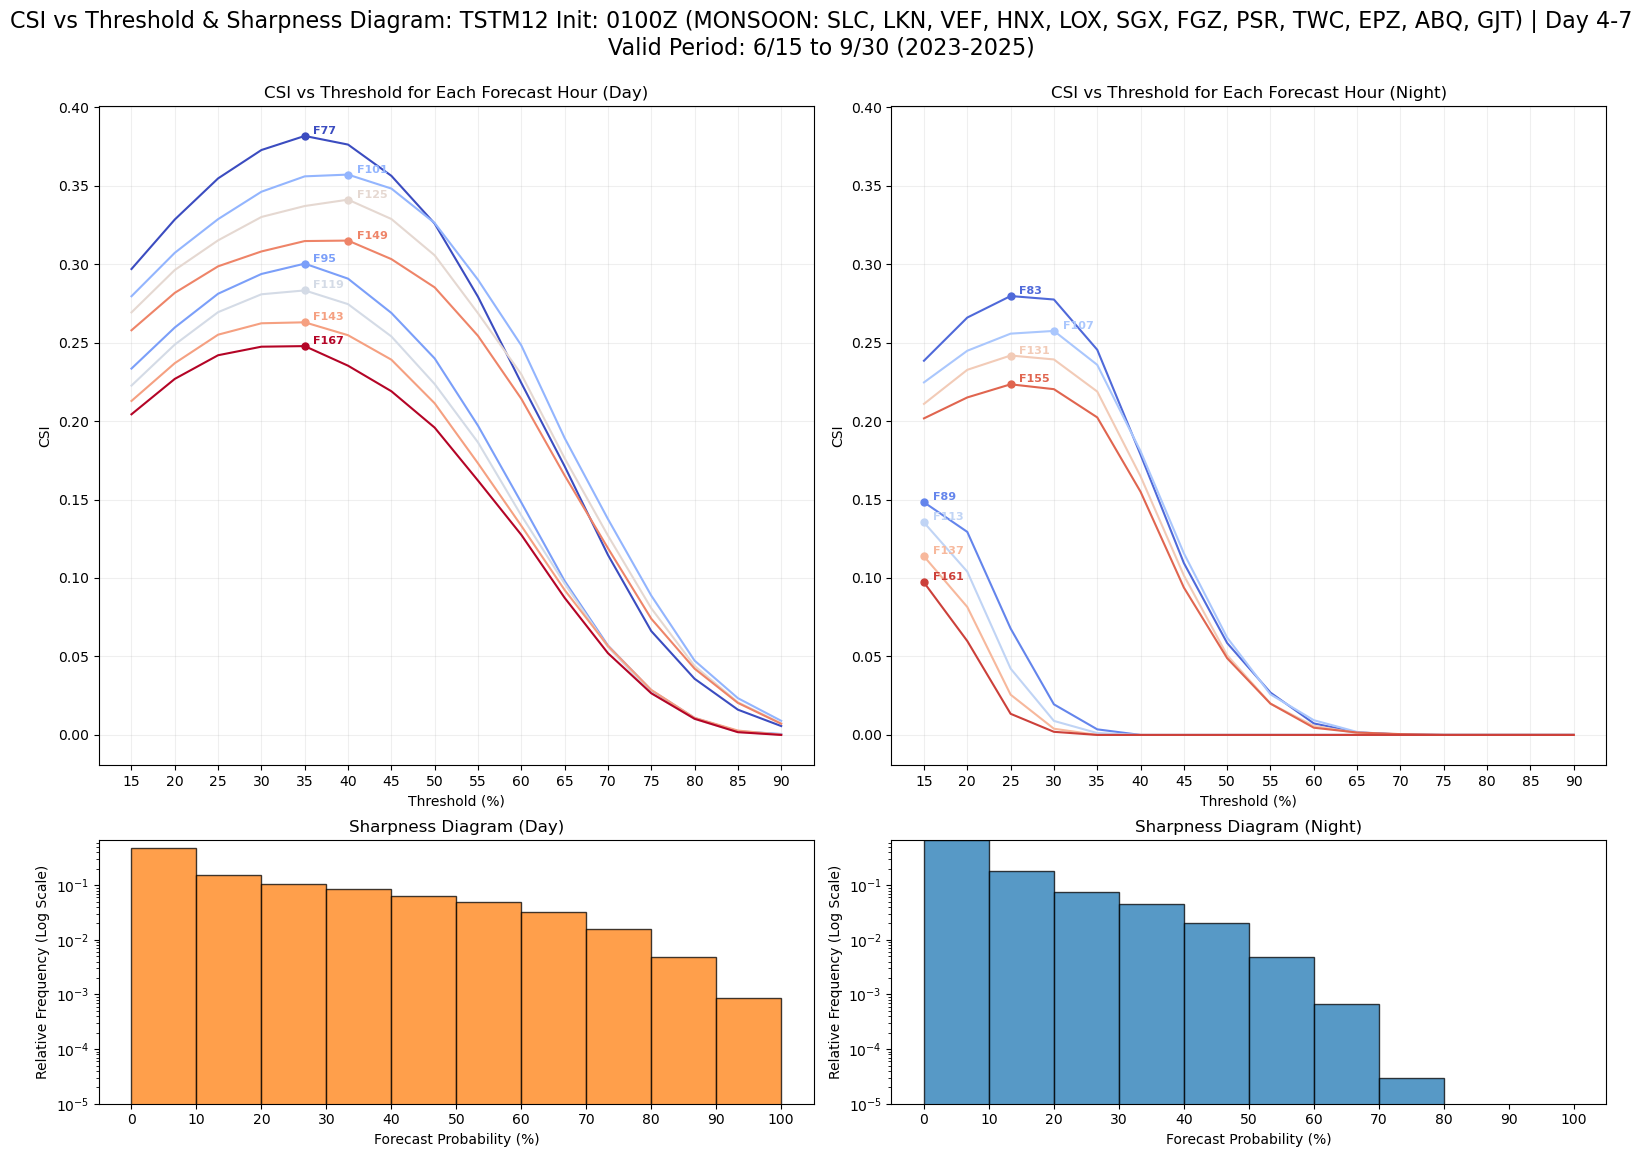

In [16]:
# MONSOON ONLY - REPEAT THE ABOVE FOR THE MONSOON SEASON AND WFOs

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import os

# Fallbacks let this cell run even if the split cell was not run first.
fcst_subset_title = globals().get('fcst_subset_title', '')
fcst_subset_file_suffix = globals().get('fcst_subset_file_suffix', '')

thresholds = np.arange(15, 95, 5) # 15 to 90

def compute_csi_by_fh_thresh(df, obs_col='observed_thunder'):
    df_eval = df[['point_prob', obs_col, 'forecast_hour']].dropna()
    obs = df_eval[obs_col].astype(int).eq(1)
    
    results = []
    for t in thresholds:
        pred = df_eval['point_prob'] >= t
        hits = (pred & obs).astype(int)
        misses = (~pred & obs).astype(int)
        fa = (pred & ~obs).astype(int)
        
        df_stats = pd.DataFrame({
            'forecast_hour': df_eval['forecast_hour'],
            'hits': hits,
            'misses': misses,
            'fa': fa
        })
        
        grouped = df_stats.groupby('forecast_hour').sum()
        
        csi = grouped['hits'] / (grouped['hits'] + grouped['misses'] + grouped['fa'])
        
        res = pd.DataFrame({
            'forecast_hour': grouped.index,
            'threshold': t,
            'CSI': csi
        })
        
        results.append(res)
        
        del df_stats, grouped, csi, res, pred, hits, misses, fa
        
    import gc
    del df_eval, obs
    gc.collect()
    
    if not results:
        return pd.DataFrame()
        
    return pd.concat(results, ignore_index=True)

wfo = ['SLC', 'LKN', 'VEF','HNX','LOX','SGX','FGZ','PSR','TWC','EPZ','ABQ','GJT']
years = [2023, 2024, 2025]
start_month, start_day = 6, 15
end_month, end_day = 9, 30

# Assuming a 'date' or similar column exists in df_day/df_night. Replace 'valid_time' with actual date column name.
# Ensure 'wfo' column or appropriate column name for station WFOs is used.
date_col = 'valid_date' # Change to the correct date/datetime column
wfo_col = 'wfo' # Change to the correct WFO column if it's different

# Calculate the precise time by adding forecast_hour to the initialization/valid time column
time_d = pd.to_datetime(df_day[date_col]) + pd.to_timedelta(df_day['forecast_hour'], unit='h')
time_n = pd.to_datetime(df_night[date_col]) + pd.to_timedelta(df_night['forecast_hour'], unit='h')

def get_date_mask(time_series, years, start_m, start_d, end_m, end_d):
    y_mask = time_series.dt.year.isin(years)
    mmdd = time_series.dt.month * 100 + time_series.dt.day
    start_val = start_m * 100 + start_d
    end_val = end_m * 100 + end_d
    return y_mask & (mmdd >= start_val) & (mmdd <= end_val)

mask_d = get_date_mask(time_d, years, start_month, start_day, end_month, end_day)
mask_n = get_date_mask(time_n, years, start_month, start_day, end_month, end_day)

# Filter by date range and WFO list
df_d = df_day[(df_day[wfo_col].isin(wfo)) & mask_d]
df_n = df_night[(df_night[wfo_col].isin(wfo)) & mask_n]

stats_day_monsoon = compute_csi_by_fh_thresh(df_d)
stats_night_monsoon = compute_csi_by_fh_thresh(df_n)

all_fhs_monsoon = set()
if not stats_day_monsoon.empty: 
    all_fhs_monsoon.update(stats_day_monsoon['forecast_hour'].unique())
if not stats_night_monsoon.empty: 
    all_fhs_monsoon.update(stats_night_monsoon['forecast_hour'].unique())

if not all_fhs_monsoon:
    print("No data for the specified WFOs and date range.")
else:
    min_fh, max_fh = min(all_fhs_monsoon), max(all_fhs_monsoon)
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1])
    
    ax_top_d = fig.add_subplot(gs[0, 0])
    ax_top_n = fig.add_subplot(gs[0, 1], sharey=ax_top_d, sharex=ax_top_d)
    ax_bot_d = fig.add_subplot(gs[1, 0])
    ax_bot_n = fig.add_subplot(gs[1, 1], sharey=ax_bot_d, sharex=ax_bot_d)
    
    fig.suptitle(f'CSI vs Threshold & Sharpness Diagram: {tstm_type.upper()} Init: {init_cyle}Z (MONSOON: {", ".join(wfo)}){fcst_subset_title}\nValid Period: {start_month}/{start_day} to {end_month}/{end_day} ({min(years)}-{max(years)})', fontsize=16, y=0.96)
    
    cmap = cm.get_cmap('coolwarm')
    
    def plot_csi_curves_monsoon(ax, stats, title):
        if stats.empty:
            return
        for fh, group in stats.groupby('forecast_hour'):
            group = group.sort_values('threshold')
            color_val = (fh - min_fh) / (max_fh - min_fh) if max_fh > min_fh else 0.5
            c = cmap(color_val)
            ax.plot(group['threshold'], group['CSI'], color=c, label=f'F{fh}')
            
            # Highlight max CSI with a dot and label
            if not group['CSI'].isna().all():
                max_csi_idx = group['CSI'].idxmax()
                max_row = group.loc[max_csi_idx]
                ax.plot(max_row['threshold'], max_row['CSI'], marker='o', markersize=5, color=c)
                ax.text(max_row['threshold'] + 1, max_row['CSI'], f"F{fh}", color=c, fontsize=8, fontweight='bold', va='bottom')
        
        ax.set_title(title)
        ax.set_xlabel('Threshold (%)')
        ax.set_ylabel('CSI')
        ax.set_xticks(thresholds)
        ax.grid(alpha=0.2)
        
    plot_csi_curves_monsoon(ax_top_d, stats_day_monsoon, 'CSI vs Threshold for Each Forecast Hour (Day)')
    plot_csi_curves_monsoon(ax_top_n, stats_night_monsoon, 'CSI vs Threshold for Each Forecast Hour (Night)')
    
    def plot_sharpness_monsoon(ax, df_sub, color, title):
        probs = df_sub['point_prob'].dropna()
        if len(probs) > 0:
            weights = np.ones_like(probs) / len(probs)
            ax.hist(probs, bins=np.arange(0, 110, 10), weights=weights, color=color, edgecolor='black', alpha=0.75)
        
        ax.set_title(title)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-5)
        ax.set_xlabel('Forecast Probability (%)')
        ax.set_ylabel('Relative Frequency (Log Scale)')
        ax.set_xticks(np.arange(0, 110, 10))
        
    plot_sharpness_monsoon(ax_bot_d, df_d, 'tab:orange', 'Sharpness Diagram (Day)')
    plot_sharpness_monsoon(ax_bot_n, df_n, 'tab:blue', 'Sharpness Diagram (Night)')
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.88)
    
    save_path = os.path.join(plot_dir, f'csi_sharpness_{tstm_type}_{init_cyle}_MONSOON{fcst_subset_file_suffix}.tif')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

## Regional Reliability and ROC Diagnostics

This section focuses on calibration and discrimination rather than threshold-based CSI. It builds reliability curves for thunder, lightning, and combined-event definitions, adds sharpness insets, and summarizes ROC behavior for the same day/night regional subsets.

Run this after the day/night split when you want to assess whether the forecast probabilities are both skillful and well calibrated.

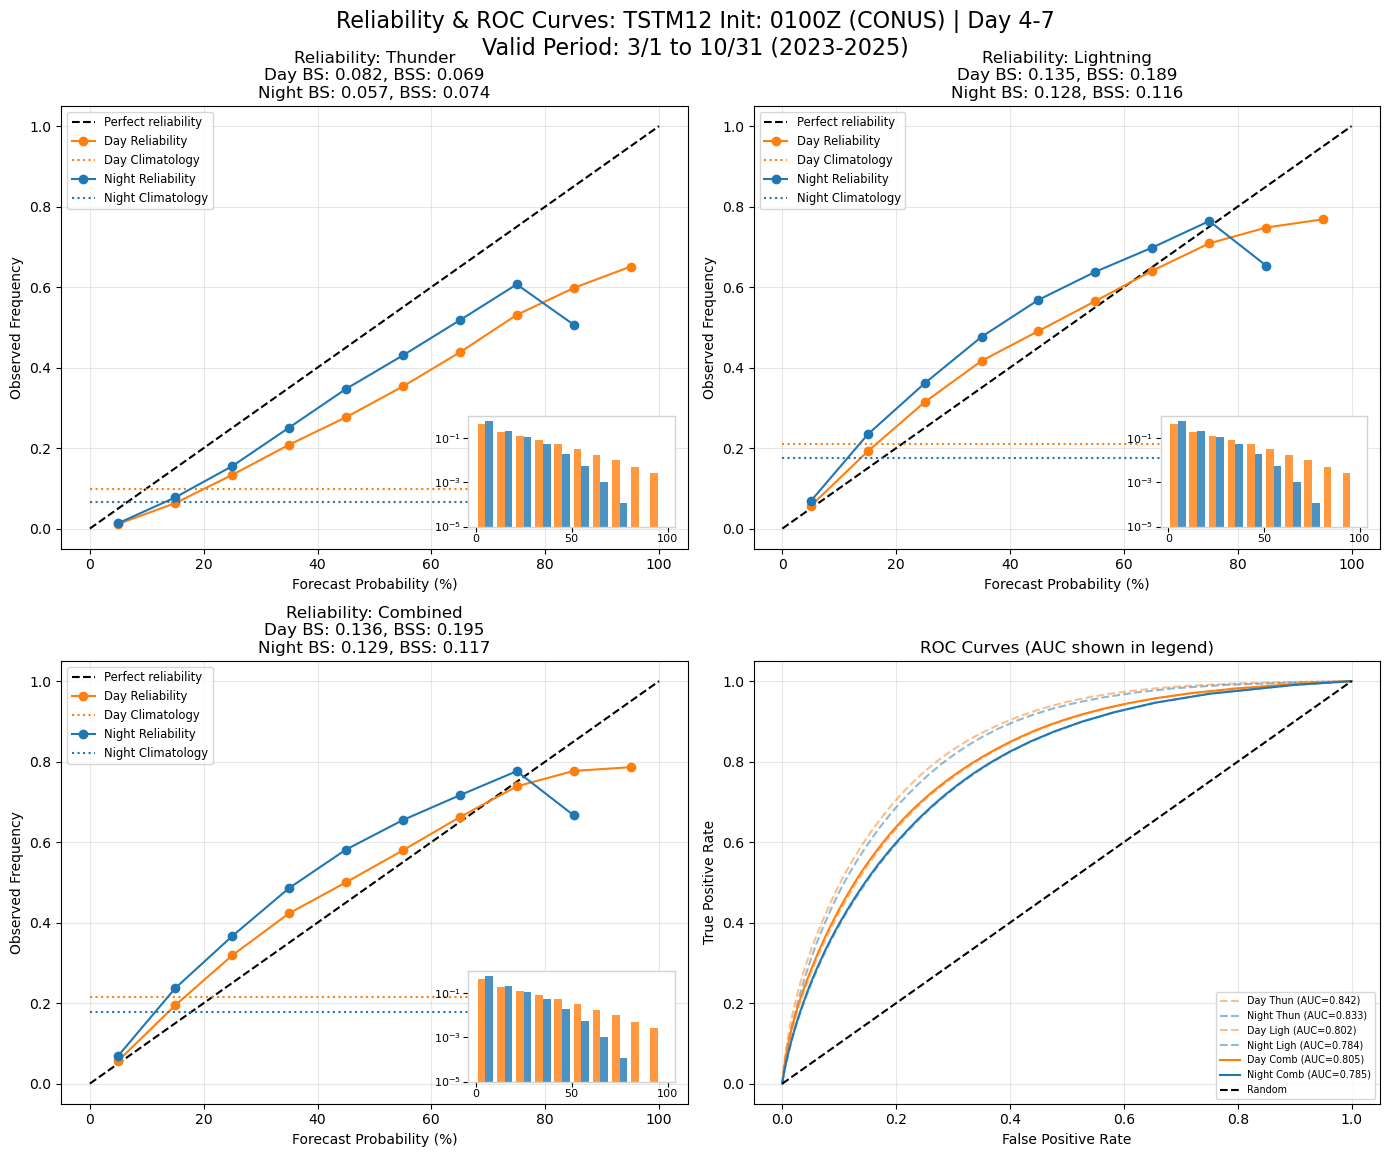

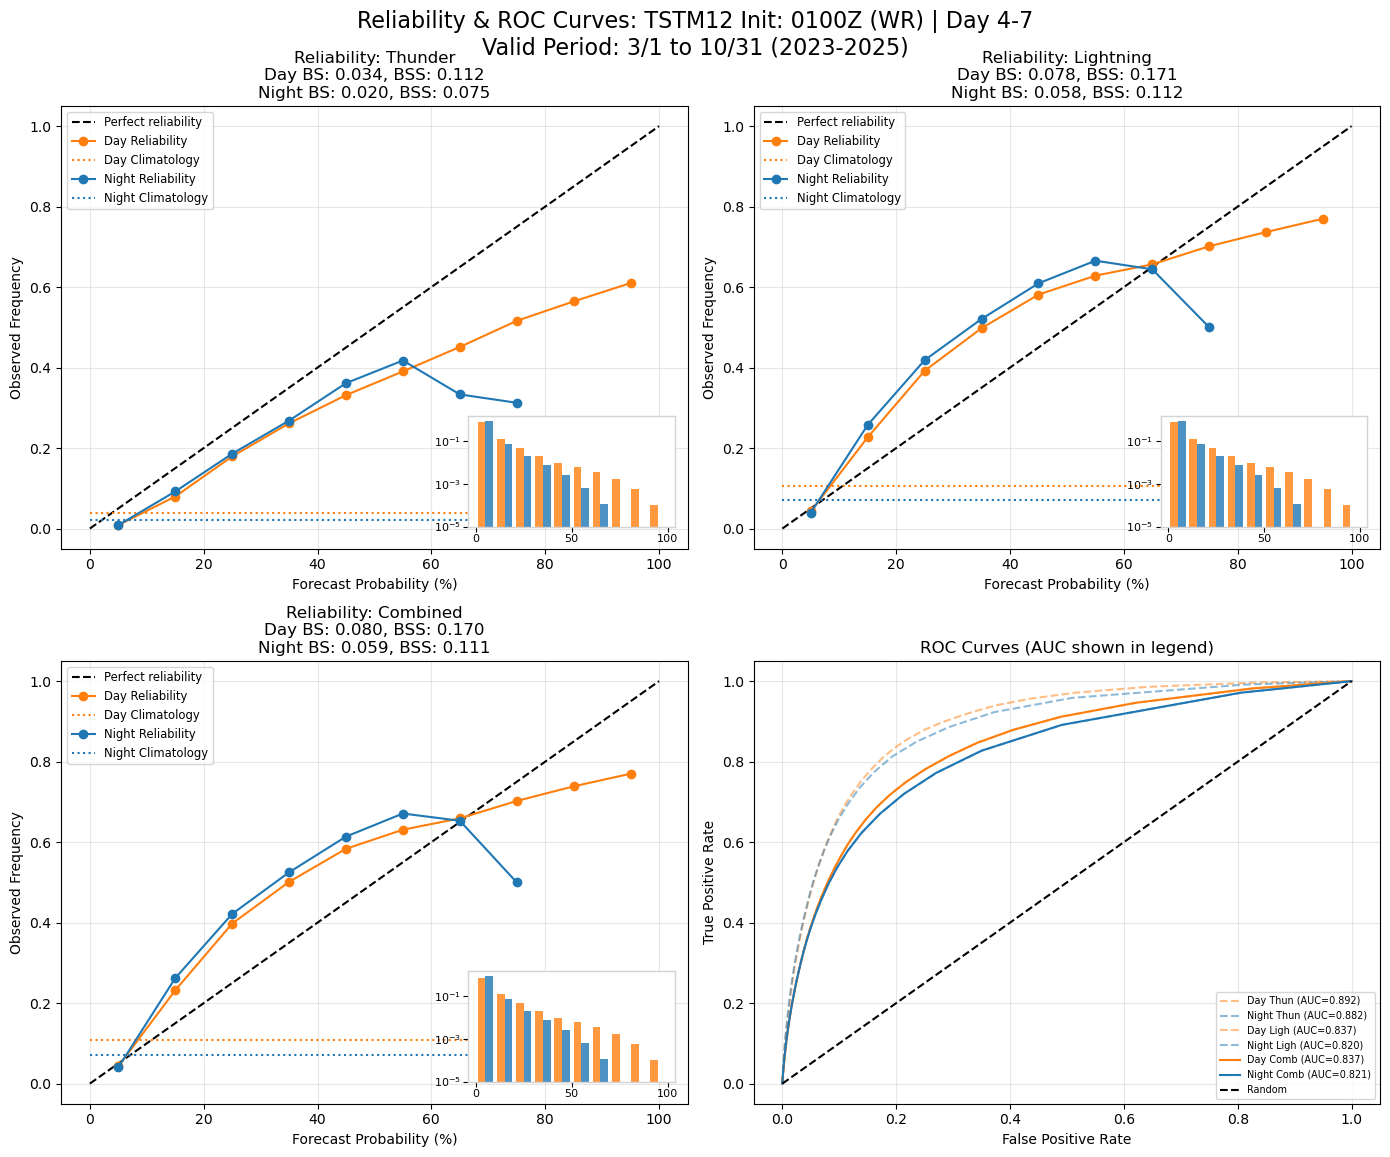

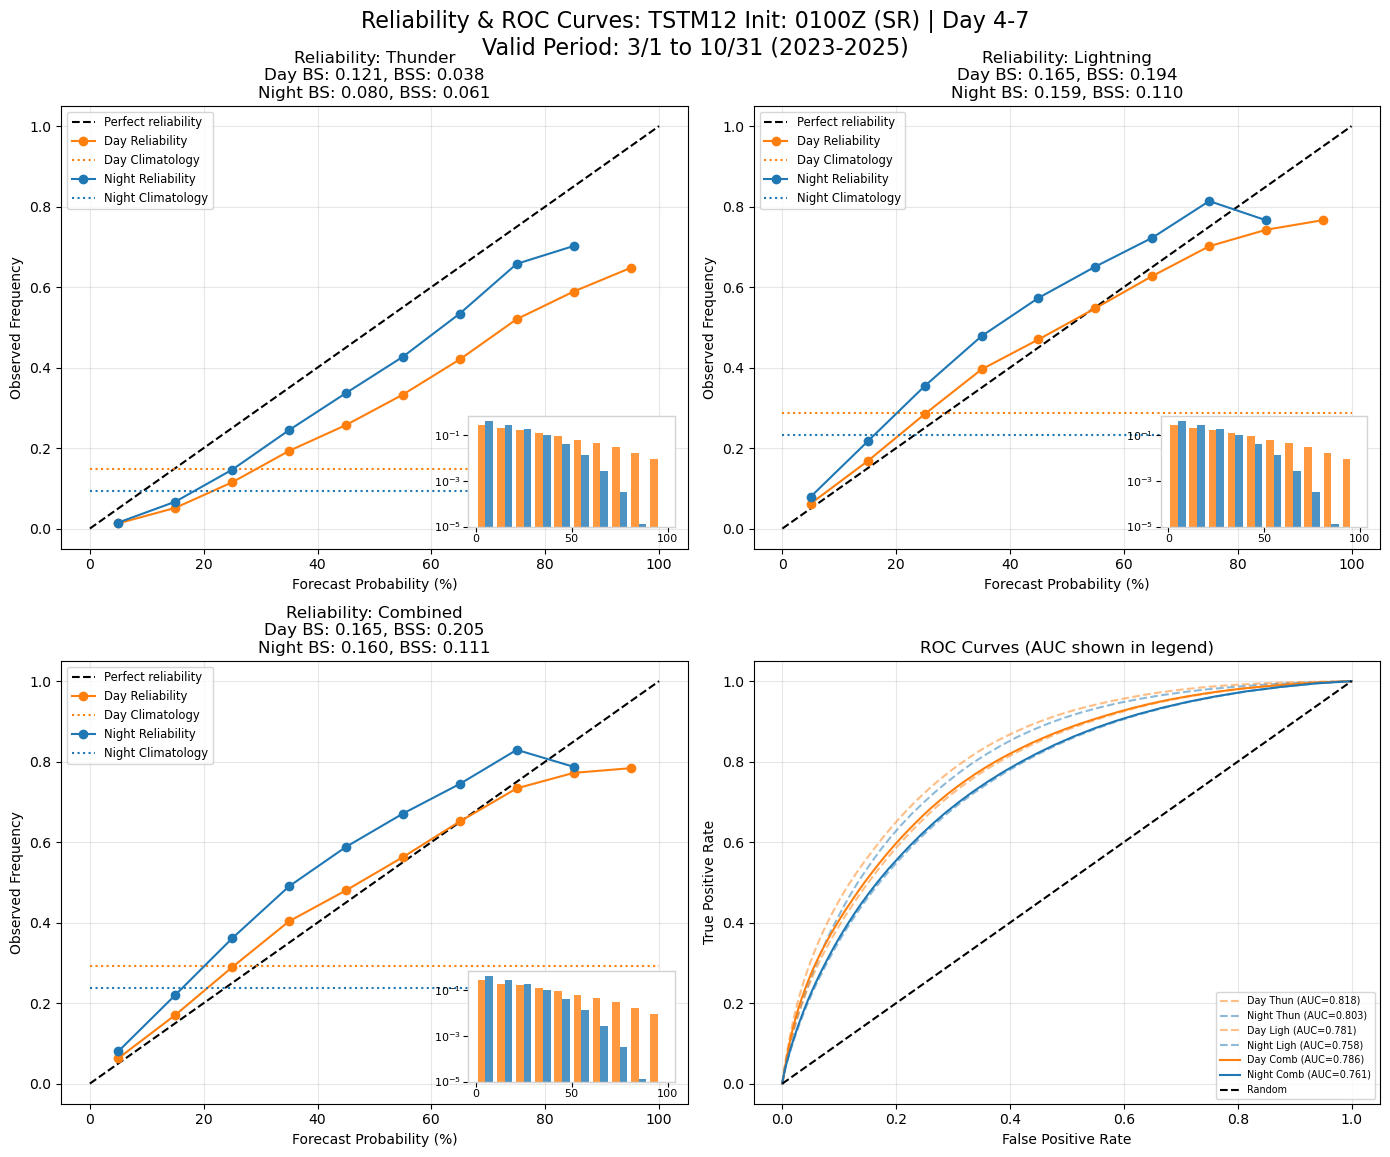

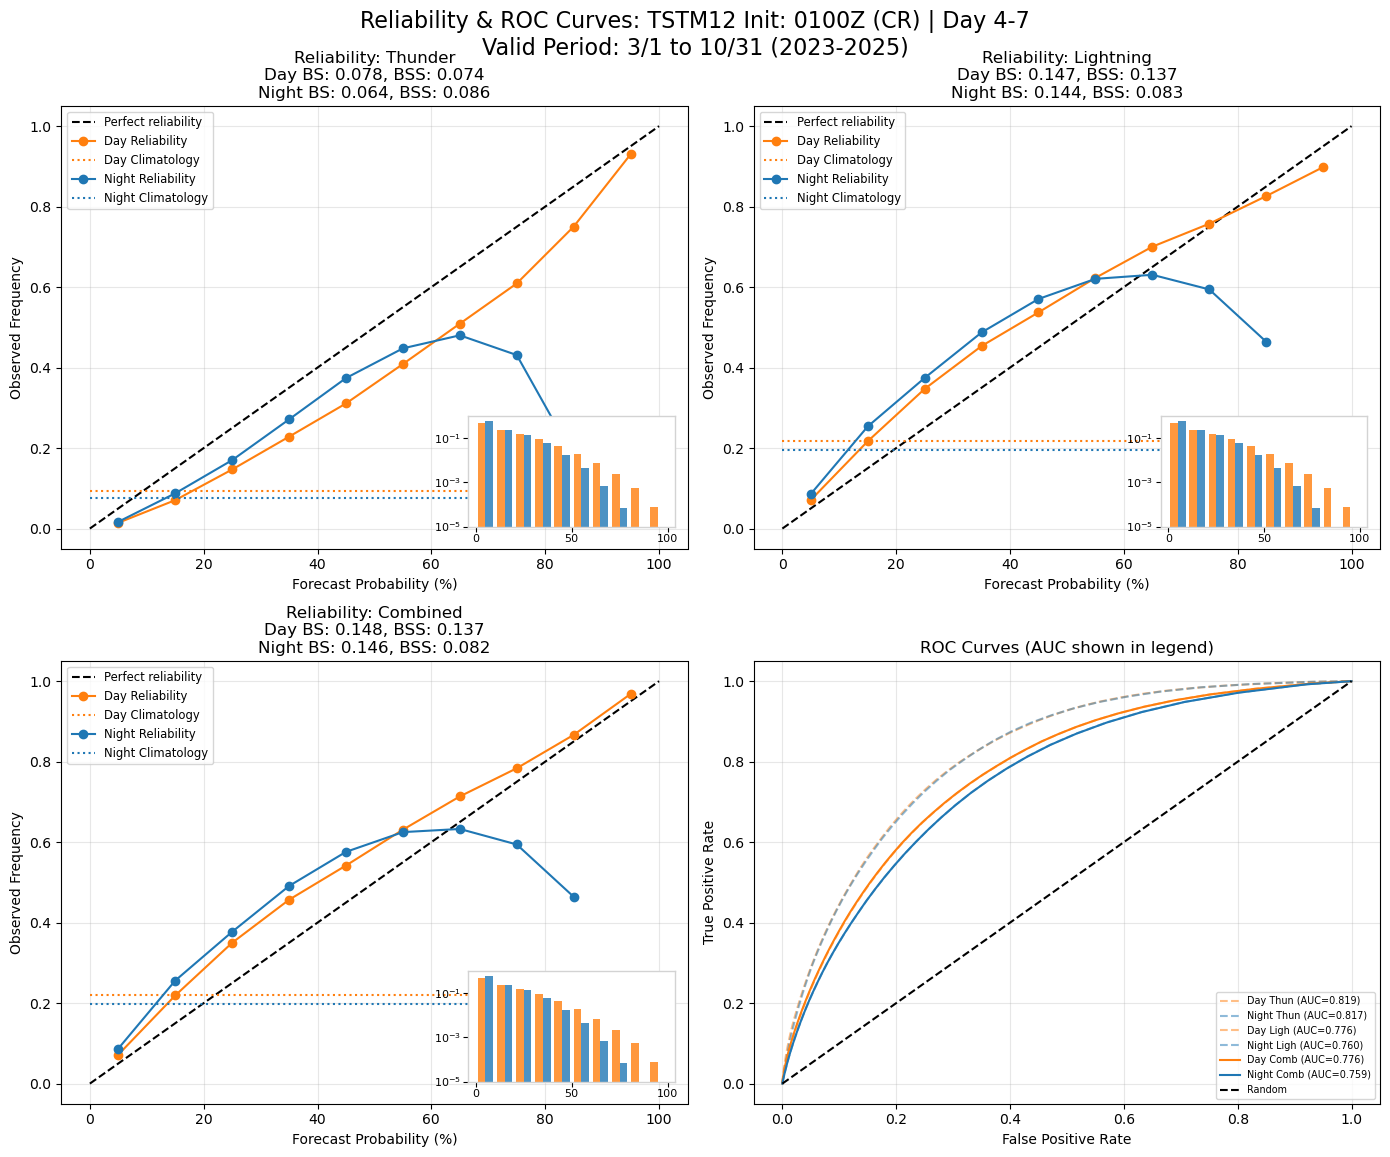

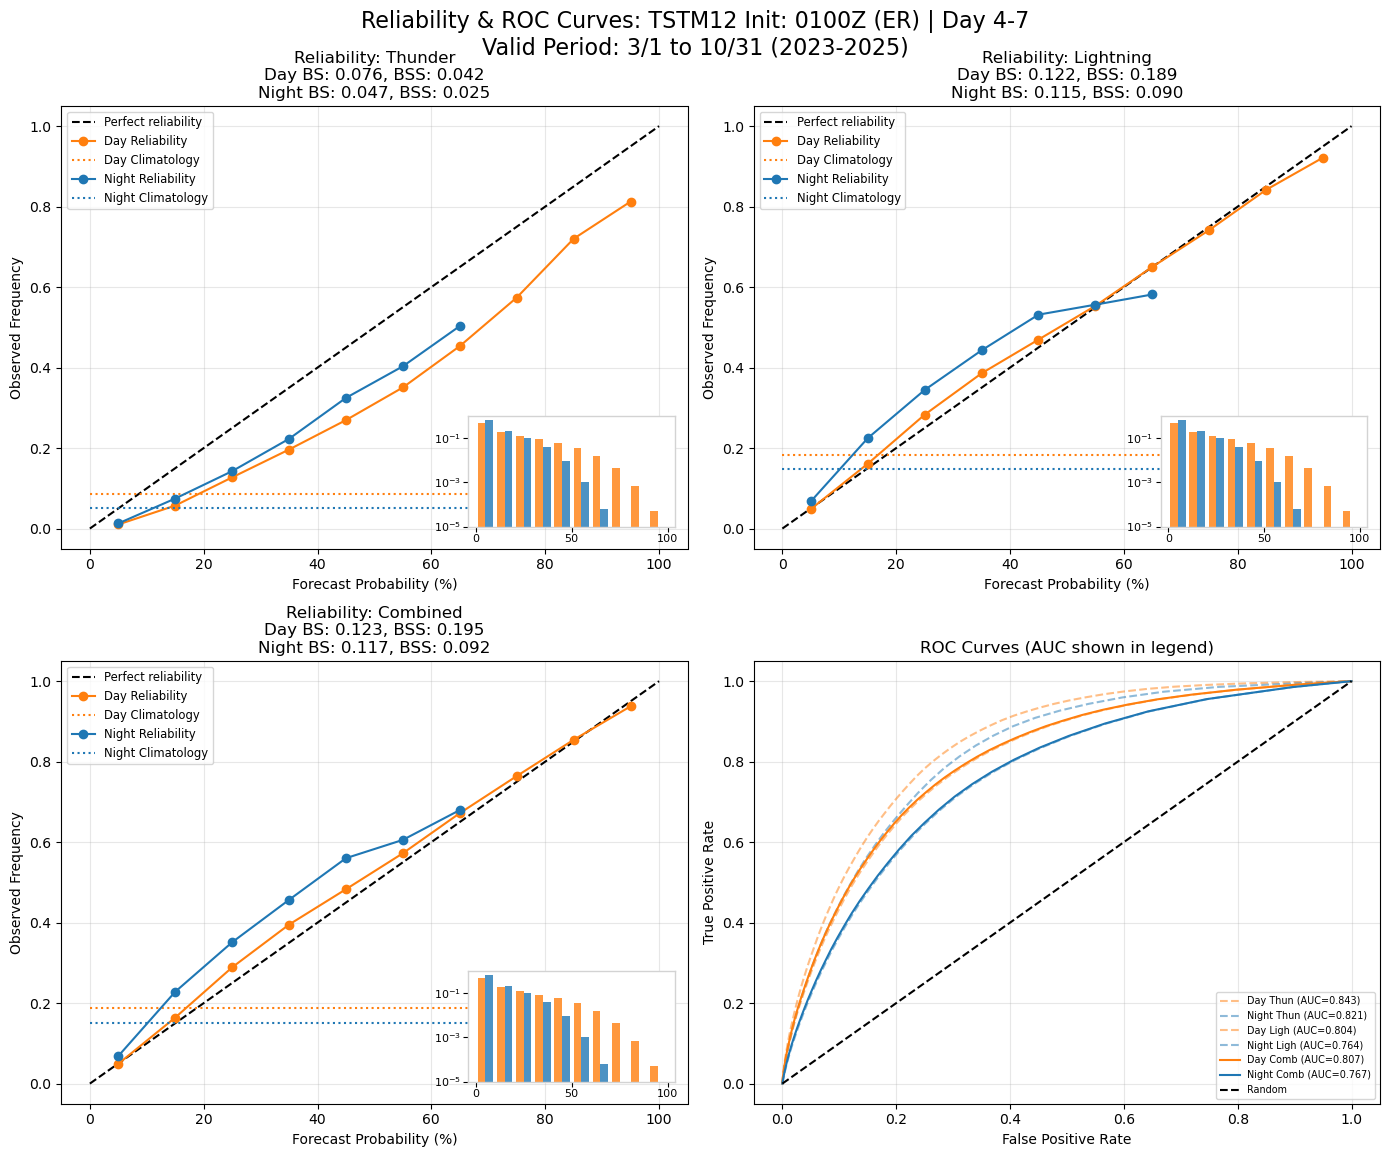

In [17]:
# Plot reliability curves with Brier score, Brier skill score, ROC/AUC curves, and reference lines for Day vs Night
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.metrics import roc_curve, auc, brier_score_loss

# Fallbacks let this cell run even if the split cell was not run first.
fcst_subset_title = globals().get('fcst_subset_title', '')
fcst_subset_file_suffix = globals().get('fcst_subset_file_suffix', '')

years = [2023, 2024, 2025]
start_month, start_day = 3, 1
end_month, end_day = 10, 31

date_col = 'valid_date' # Change to the correct date/datetime column

time_d_all = pd.to_datetime(df_day[date_col]) + pd.to_timedelta(df_day['forecast_hour'], unit='h')
time_n_all = pd.to_datetime(df_night[date_col]) + pd.to_timedelta(df_night['forecast_hour'], unit='h')

def get_date_mask(time_series, years, start_m, start_d, end_m, end_d):
    y_mask = time_series.dt.year.isin(years)
    mmdd = time_series.dt.month * 100 + time_series.dt.day
    start_val = start_m * 100 + start_d
    end_val = end_m * 100 + end_d
    return y_mask & (mmdd >= start_val) & (mmdd <= end_val)

mask_d_all = get_date_mask(time_d_all, years, start_month, start_day, end_month, end_day)
mask_n_all = get_date_mask(time_n_all, years, start_month, start_day, end_month, end_day)

df_day_filtered = df_day[mask_d_all]
df_night_filtered = df_night[mask_n_all]

bin_edges = np.arange(0, 110, 10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

colors = {'Day': 'tab:orange', 'Night': 'tab:blue'}

def reliability_curve(probs, obs, bins):
    bin_indices = np.digitize(probs, bins) - 1
    reliability = np.zeros(len(bins) - 1)
    counts = np.zeros(len(bins) - 1)
    for i in range(len(bins) - 1):
        mask = bin_indices == i
        if np.any(mask):
            reliability[i] = obs[mask].mean()
            counts[i] = mask.sum()
        else:
            reliability[i] = np.nan
    return reliability, counts

regions = ['CONUS', 'WR', 'SR', 'CR', 'ER']

for region in regions:
    if region == 'CONUS':
        df_day_region = df_day_filtered
        df_night_region = df_night_filtered
    else:
        df_day_region = df_day_filtered[df_day_filtered['region'] == region]
        df_night_region = df_night_filtered[df_night_filtered['region'] == region]
        
    datasets = {
        'Day': df_day_region[['point_prob', 'observed_thunder', 'observed_lightning', 'observed_combined']].dropna(),
        'Night': df_night_region[['point_prob', 'observed_thunder', 'observed_lightning', 'observed_combined']].dropna()
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Reliability & ROC Curves: {tstm_type.upper()} Init: {init_cyle}Z ({region}){fcst_subset_title}\nValid Period: {start_month}/{start_day} to {end_month}/{end_day} ({min(years)}-{max(years)})', fontsize=16, y=0.96)

    # Subplot definitions: (ax, label_prefix, observed_col)
    panels = [
        (axes[0, 0], 'Thunder', 'observed_thunder'),
        (axes[0, 1], 'Lightning', 'observed_lightning'),
        (axes[1, 0], 'Combined', 'observed_combined'),
    ]

    roc_ax = axes[1, 1]

    for ax, title_prefix, col in panels:
        ax.plot([0,100], [0,1], 'k--', label='Perfect reliability')
        
        title_str = f'Reliability: {title_prefix}'
        
        # Create inset axis for sharpness plot in bottom right corner
        # The list is [left, bottom, width, height] in normalized coordinates of the parent ax.
        # Set it to bottom right, carefully avoiding zero values which cause errors on log scale and clipping labels.
        inset_ax = ax.inset_axes([0.65, 0.05, 0.33, 0.25])
        inset_ax.set_facecolor('white') # Explicitly add white background
        
        # Add a thin border to separate it cleanly from lines behind it
        for spine in inset_ax.spines.values():
            spine.set_edgecolor('lightgray')
            spine.set_linewidth(1.0)
        
        all_inset_probs = []
        all_inset_colors = []
        
        for label, plot_df in datasets.items():
            if len(plot_df) == 0:
                continue
                
            obs_vals = plot_df[col].values
            probs_val = plot_df['point_prob'].values
            probs_norm = probs_val / 100
            
            rel, _ = reliability_curve(probs_val, obs_vals, bin_edges)
            clim = np.mean(obs_vals)
            
            brier = brier_score_loss(obs_vals, probs_norm)
            brier_ref = brier_score_loss(obs_vals, np.full_like(probs_norm, clim))
            
            # Handle potential division by zero for BSS
            if brier_ref > 0:
                bss = 1 - brier / brier_ref
            else:
                bss = np.nan
            
            ax.plot(bin_centers, rel, marker='o', color=colors[label], label=f'{label} Reliability')
            ax.hlines(clim, 0, 100, colors=colors[label], linestyles=':', label=f'{label} Climatology')

            title_str += f'\n{label} BS: {brier:.3f}, BSS: {bss:.3f}'
            
            # Accumulate probabilities for the inset sharpness plot
            all_inset_probs.append(probs_val)
            all_inset_colors.append(colors[label])
            
            # Calculate ROC for the bottom-right panel
            # Need at least one positive and one negative class
            if len(np.unique(obs_vals)) > 1:
                fpr, tpr, _ = roc_curve(obs_vals, probs_norm)
                auc_val = auc(fpr, tpr)
                roc_ax.plot(fpr, tpr, color=colors[label], 
                            linestyle='-' if title_prefix == 'Combined' else '--',
                            alpha=1.0 if title_prefix == 'Combined' else 0.5,
                            label=f'{label} {title_prefix[:4]} (AUC={auc_val:.3f})')
                        
        # Plot grouped histogram on the inset axis 
        n_bins = np.arange(0, 110, 10)
        
        if len(all_inset_probs) > 0:
            weights = [np.ones_like(p)/len(p) for p in all_inset_probs]
            
            inset_ax.hist(all_inset_probs, bins=n_bins, color=all_inset_colors, 
                          edgecolor='none', alpha=0.8, weights=weights, stacked=False)
                      
        inset_ax.set_yscale('log')
        # Set a small lower limit so empty bins don't crash the log scale rendering
        inset_ax.set_ylim(bottom=1e-5) 
        inset_ax.set_xticks([0, 50, 100])
        inset_ax.tick_params(axis='both', which='major', labelsize=8)
        inset_ax.grid(False)
        
        # Optional: Slightly pad the labels so they don't hit the text edge if they run over
        inset_ax.tick_params(pad=2)

        ax.set_title(title_str)
        ax.set_xlabel('Forecast Probability (%)')
        ax.set_ylabel('Observed Frequency')
        ax.grid(alpha=0.3)
        
        # Only add legend if we actually plotted something
        if len(all_inset_probs) > 0:
            ax.legend(fontsize='small', loc='upper left')
        
    roc_ax.plot([0,1], [0,1], 'k--', label='Random')
    roc_ax.set_title('ROC Curves (AUC shown in legend)')
    roc_ax.set_xlabel('False Positive Rate')
    roc_ax.set_ylabel('True Positive Rate')
    roc_ax.grid(alpha=0.3)
    # Put legend outside or use smaller font since it will have 6 entries
    roc_ax.legend(loc='lower right', fontsize='x-small')

    plt.tight_layout()
    fig.subplots_adjust(top=0.88) # Leave space for suptitle

    # Save the plot
    plt.savefig(os.path.join(plot_dir, f'reliability_roc_{tstm_type}_{init_cyle}_{region}{fcst_subset_file_suffix}.png'), dpi=300, bbox_inches='tight')

    plt.show()

## Monsoon Reliability and ROC Diagnostics

This final plot section applies the reliability and ROC workflow to the monsoon WFO subset. Use it when you want calibration and discrimination diagnostics that align with the monsoon-specific CSI figures above, using the same seasonal window and office list.

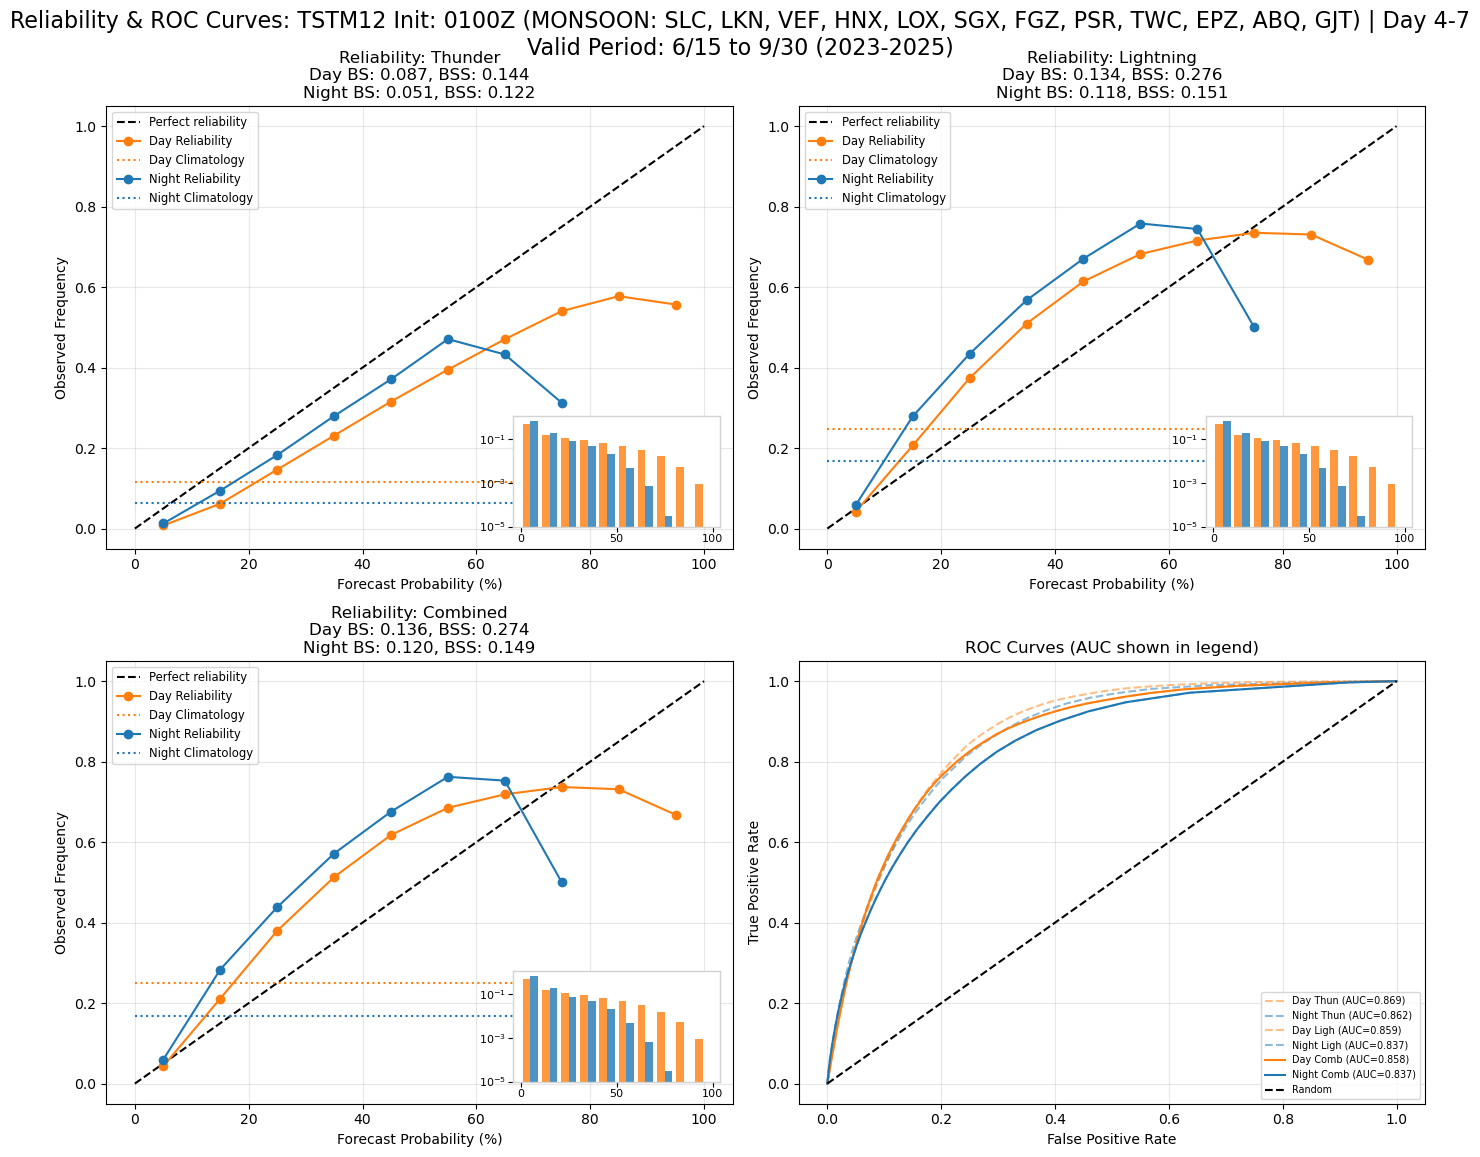

In [18]:
### MONSOON-ONLY RELIABILITY & ROC CURVES WITH BSS, AUC, AND SHARPNESS INSETS

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.metrics import roc_curve, auc, brier_score_loss

# Fallbacks let this cell run even if the split cell was not run first.
fcst_subset_title = globals().get('fcst_subset_title', '')
fcst_subset_file_suffix = globals().get('fcst_subset_file_suffix', '')

wfo = ['SLC', 'LKN', 'VEF','HNX','LOX','SGX','FGZ','PSR','TWC','EPZ','ABQ','GJT']
years = [2023, 2024, 2025]
start_month, start_day = 6, 15
end_month, end_day = 9, 30

# Assuming a 'date' or similar column exists in df_day/df_night. Replace 'valid_date' with actual date column name.
# Ensure 'wfo' column or appropriate column name for station WFOs is used.
date_col = 'valid_date' # Change to the correct date/datetime column
wfo_col = 'wfo' # Change to the correct WFO column if it's different

# Calculate the precise time by adding forecast_hour to the initialization/valid time column
time_d = pd.to_datetime(df_day[date_col]) + pd.to_timedelta(df_day['forecast_hour'], unit='h')
time_n = pd.to_datetime(df_night[date_col]) + pd.to_timedelta(df_night['forecast_hour'], unit='h')

def get_date_mask(time_series, years, start_m, start_d, end_m, end_d):
    y_mask = time_series.dt.year.isin(years)
    mmdd = time_series.dt.month * 100 + time_series.dt.day
    start_val = start_m * 100 + start_d
    end_val = end_m * 100 + end_d
    return y_mask & (mmdd >= start_val) & (mmdd <= end_val)

mask_d = get_date_mask(time_d, years, start_month, start_day, end_month, end_day)
mask_n = get_date_mask(time_n, years, start_month, start_day, end_month, end_day)

# Filter by date range and WFO list
df_d = df_day[(df_day[wfo_col].isin(wfo)) & mask_d]
df_n = df_night[(df_night[wfo_col].isin(wfo)) & mask_n]


bin_edges = np.arange(0, 110, 10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

colors = {'Day': 'tab:orange', 'Night': 'tab:blue'}

def reliability_curve(probs, obs, bins):
    bin_indices = np.digitize(probs, bins) - 1
    reliability = np.zeros(len(bins) - 1)
    counts = np.zeros(len(bins) - 1)
    for i in range(len(bins) - 1):
        mask = bin_indices == i
        if np.any(mask):
            reliability[i] = obs[mask].mean()
            counts[i] = mask.sum()
        else:
            reliability[i] = np.nan
    return reliability, counts

datasets = {
    'Day': df_d[['point_prob', 'observed_thunder', 'observed_lightning', 'observed_combined']].dropna(),
    'Night': df_n[['point_prob', 'observed_thunder', 'observed_lightning', 'observed_combined']].dropna()
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'Reliability & ROC Curves: {tstm_type.upper()} Init: {init_cyle}Z (MONSOON: {", ".join(wfo)}){fcst_subset_title}\nValid Period: {start_month}/{start_day} to {end_month}/{end_day} ({min(years)}-{max(years)})', fontsize=16, y=0.96)

# Subplot definitions: (ax, label_prefix, observed_col)
panels = [
    (axes[0, 0], 'Thunder', 'observed_thunder'),
    (axes[0, 1], 'Lightning', 'observed_lightning'),
    (axes[1, 0], 'Combined', 'observed_combined'),
]

roc_ax = axes[1, 1]

for ax, title_prefix, col in panels:
    ax.plot([0,100], [0,1], 'k--', label='Perfect reliability')
    
    title_str = f'Reliability: {title_prefix}'
    
    # Create inset axis for sharpness plot in bottom right corner
    inset_ax = ax.inset_axes([0.65, 0.05, 0.33, 0.25])
    inset_ax.set_facecolor('white') # Explicitly add white background
    
    # Add a thin border to separate it cleanly from lines behind it
    for spine in inset_ax.spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1.0)
    
    all_inset_probs = []
    all_inset_colors = []
    
    for label, plot_df in datasets.items():
        if len(plot_df) == 0:
            continue
            
        obs_vals = plot_df[col].values
        probs_val = plot_df['point_prob'].values
        probs_norm = probs_val / 100
        
        rel, _ = reliability_curve(probs_val, obs_vals, bin_edges)
        clim = np.mean(obs_vals)
        
        brier = brier_score_loss(obs_vals, probs_norm)
        brier_ref = brier_score_loss(obs_vals, np.full_like(probs_norm, clim))
        
        # Handle potential division by zero for BSS
        if brier_ref > 0:
            bss = 1 - brier / brier_ref
        else:
            bss = np.nan
            
        # For binary events, CRPS is mathematically identical to the Brier Score. 
        # Adding them here to provide the expected metrics in the plot standard.
        crps = brier
        crpss = bss
        
        ax.plot(bin_centers, rel, marker='o', color=colors[label], label=f'{label} Reliability')
        ax.hlines(clim, 0, 100, colors=colors[label], linestyles=':', label=f'{label} Climatology')

        title_str += f'\n{label} BS: {brier:.3f}, BSS: {bss:.3f}'
        
        # Accumulate probabilities for the inset sharpness plot
        all_inset_probs.append(probs_val)
        all_inset_colors.append(colors[label])
        
        # Calculate ROC for the bottom-right panel
        if len(np.unique(obs_vals)) > 1:
            fpr, tpr, _ = roc_curve(obs_vals, probs_norm)
            auc_val = auc(fpr, tpr)
            roc_ax.plot(fpr, tpr, color=colors[label], 
                        linestyle='-' if title_prefix == 'Combined' else '--',
                        alpha=1.0 if title_prefix == 'Combined' else 0.5,
                        label=f'{label} {title_prefix[:4]} (AUC={auc_val:.3f})')
                    
    # Plot grouped histogram on the inset axis 
    n_bins = np.arange(0, 110, 10)
    
    if len(all_inset_probs) > 0:
        weights = [np.ones_like(p)/len(p) for p in all_inset_probs]
        
        inset_ax.hist(all_inset_probs, bins=n_bins, color=all_inset_colors, 
                      edgecolor='none', alpha=0.8, weights=weights, stacked=False)
                  
    inset_ax.set_yscale('log')
    # Set a small lower limit so empty bins don't crash the log scale rendering
    inset_ax.set_ylim(bottom=1e-5) 
    inset_ax.set_xticks([0, 50, 100])
    inset_ax.tick_params(axis='both', which='major', labelsize=8)
    inset_ax.grid(False)
    
    # Optional: Slightly pad the labels so they don't hit the text edge if they run over
    inset_ax.tick_params(pad=2)

    ax.set_title(title_str)
    ax.set_xlabel('Forecast Probability (%)')
    ax.set_ylabel('Observed Frequency')
    ax.grid(alpha=0.3)
    
    if len(all_inset_probs) > 0:
        ax.legend(fontsize='small', loc='upper left')
    
roc_ax.plot([0,1], [0,1], 'k--', label='Random')
roc_ax.set_title('ROC Curves (AUC shown in legend)')
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.grid(alpha=0.3)
# Put legend outside or use smaller font since it will have up to 6 entries
roc_ax.legend(loc='lower right', fontsize='x-small')

plt.tight_layout()
fig.subplots_adjust(top=0.88) # Leave more space for suptitle

# Save the plot
save_path = os.path.join(plot_dir, f'reliability_roc_{tstm_type}_{init_cyle}_MONSOON{fcst_subset_file_suffix}.tif')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()